<a href="https://colab.research.google.com/github/TejshreeRameshKarande/Deep_Learning/blob/main/Experimet_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [ ]:
x_train = x_train[:10000]
y_train = y_train[:10000]

x_test = x_test[:2000]
y_test = y_test[:2000]

In [ ]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Resize (lightweight)
x_train = tf.image.resize(x_train, (96, 96))
x_test = tf.image.resize(x_test, (96, 96))

In [ ]:
base_model = MobileNetV2(weights='imagenet',
                         include_top=False,
                         input_shape=(96,96,3))

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history1 = model.fit(x_train, y_train,
                     epochs=3,
                     validation_data=(x_test, y_test))

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 95s 280ms/step - accuracy: 0.6902 - loss: 0.8862 - val_accuracy: 0.7610 - val_loss: 0.6806
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 233ms/step - accuracy: 0.7893 - loss: 0.5999 - val_accuracy: 0.7705 - val_loss: 0.6390
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 228ms/step - accuracy: 0.8257 - loss: 0.5028 - val_accuracy: 0.7765 - val_loss: 0.6326


In [ ]:
for layer in base_model.layers[-10:]:
    layer.trainable = True

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history2 = model.fit(x_train, y_train,
                     epochs=3,
                     validation_data=(x_test, y_test))

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 111s 318ms/step - accuracy: 0.7367 - loss: 0.7770 - val_accuracy: 0.7610 - val_loss: 0.7238
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 136s 297ms/step - accuracy: 0.8010 - loss: 0.5798 - val_accuracy: 0.7680 - val_loss: 0.7102
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 298ms/step - accuracy: 0.8164 - loss: 0.5276 - val_accuracy: 0.7720 - val_loss: 0.6883


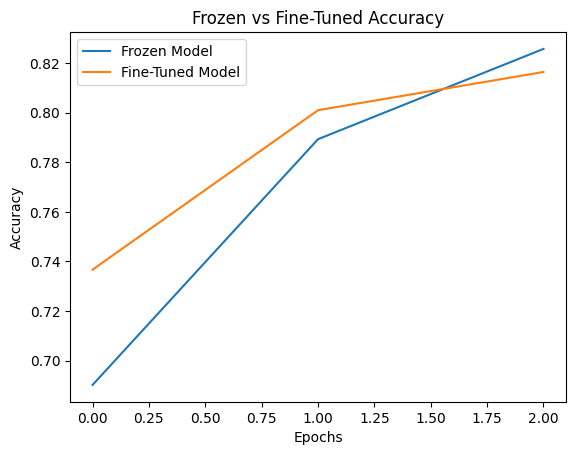

In [ ]:
plt.plot(history1.history['accuracy'], label='Frozen Model')
plt.plot(history2.history['accuracy'], label='Fine-Tuned Model')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Frozen vs Fine-Tuned Accuracy')
plt.legend()
plt.show()

In [ ]:
pred = model.predict(x_test)
print("Predicted class:", pred[0].argmax())

63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 214ms/step
Predicted class: 3
